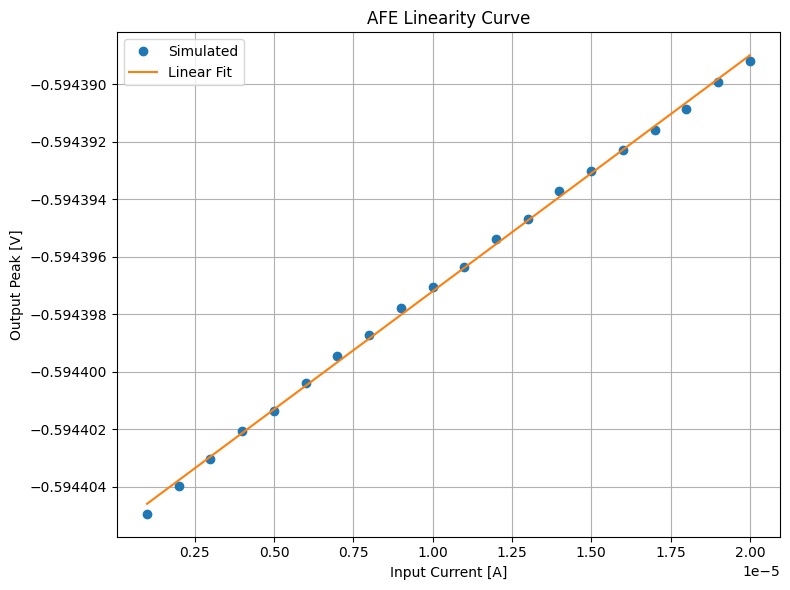

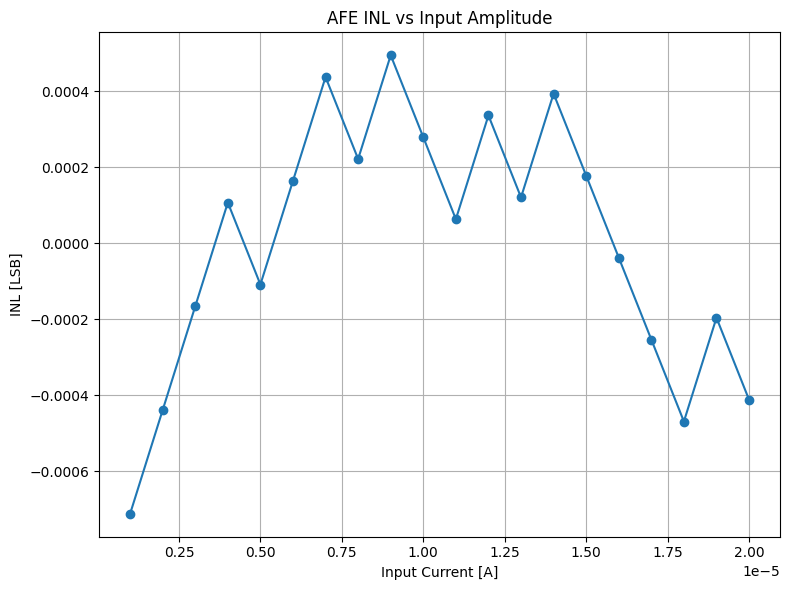


========== AFE LINEARITY REPORT ==========
Max INL (Volts):     3.474099e-07 V
Max INL (Percent):   0.000058 %
Max INL (LSB):       0.0007 LSB



In [1]:
from PyLTSpice import RawRead
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# Configuration
# ============================================================
raw_path = "/workspace/Architecture/Analysis/CircuitModels/AFE/TestBenchTransientPulseSlow.raw"
report_root = "/workspace/Architecture/Analysis/CircuitModels/AFE/Reports"
os.makedirs(report_root, exist_ok=True)

ADC_BITS = 12
ADC_FS_VOLTAGE = 2.0  # Full-scale differential input range (adjust if needed)
ADC_LSB = ADC_FS_VOLTAGE / (2**ADC_BITS)

# ============================================================
# Load RAW File
# ============================================================
raw = RawRead(raw_path)

time = raw.get_trace("time").get_wave(0)
steps = raw.get_steps()

input_amplitudes = []
output_peaks = []

# ============================================================
# Extract peak per step
# ============================================================
steps = raw.get_steps()
num_steps = len(steps)

# Reconstruct stepped current amplitudes (1u to 20u)
input_amplitudes = np.linspace(1e-6, 20e-6, num_steps)

for step_index in steps:
    vout_p = raw.get_trace("V(out_p)").get_wave(step_index)
    vout_n = raw.get_trace("V(out_n)").get_wave(step_index)

    vdiff = np.real(vout_p - vout_n)
    peak_value = np.max(vdiff)
    output_peaks.append(peak_value)

output_peaks = np.array(output_peaks)

# ============================================================
# Linear Fit
# ============================================================
coeffs = np.polyfit(input_amplitudes, output_peaks, 1)
fit_line = np.polyval(coeffs, input_amplitudes)

# ============================================================
# INL Calculation
# INL = deviation from ideal straight line
# ============================================================
inl_volts = output_peaks - fit_line
inl_percent = (inl_volts / np.max(np.abs(fit_line))) * 100
inl_lsb = inl_volts / ADC_LSB

max_inl_volts = np.max(np.abs(inl_volts))
max_inl_percent = np.max(np.abs(inl_percent))
max_inl_lsb = np.max(np.abs(inl_lsb))

# ============================================================
# Plot Linearity Curve
# ============================================================
plt.figure(figsize=(8,6))
plt.plot(input_amplitudes, output_peaks, 'o', label="Simulated")
plt.plot(input_amplitudes, fit_line, '-', label="Linear Fit")
plt.xlabel("Input Current [A]")
plt.ylabel("Output Peak [V]")
plt.title("AFE Linearity Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(report_root, "AFE_Linearity_Curve.svg"))
plt.show()

# ============================================================
# Plot INL
# ============================================================
plt.figure(figsize=(8,6))
plt.plot(input_amplitudes, inl_lsb, 'o-')
plt.xlabel("Input Current [A]")
plt.ylabel("INL [LSB]")
plt.title("AFE INL vs Input Amplitude")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(report_root, "AFE_INL.svg"))
plt.show()

# ============================================================
# Summary
# ============================================================
print("\n========== AFE LINEARITY REPORT ==========")
print(f"Max INL (Volts):     {max_inl_volts:.6e} V")
print(f"Max INL (Percent):   {max_inl_percent:.6f} %")
print(f"Max INL (LSB):       {max_inl_lsb:.4f} LSB")
print("==========================================\n")